# Anna Karenina test: does idiosyncratic cognitive abnormality track symptoms?

The CCA ladder found only a small, essentially linear *shared* cognition↔symptom axis. The **Anna Karenina hypothesis** is that symptomatic individuals are each abnormal *in their own way*, so the *magnitude/extremeness* of a person's deviation from healthy cognitive norms should track symptoms even when no shared axis exists.

We build normative models on training-half healthy volunteers (`cogmood_analysis.normative`), score every training subject's deviation (`|z|`) per cognitive parameter, and test three ways (all on **extremeness**, since signed deviations carry a random sign under AK):
- **max|z| / top-k mean** — unsupervised, robust to sparsity (primary AK statistic)
- **elastic-net on |z|** — supervised, learns the relevant subset; nested CV (hyperparameters selected inside each fold) and true out-of-fold R²=1−SSE/SST, with each permutation re-running the full selection+OOF pipeline
- **distance / count-burden** — dilution-prone baselines

Targets: symptom summary totals + subscales + a general PC1 factor, raw and age/sex-residualized. **PC1 (residualized) is the pre-specified primary**; the rest are FDR-corrected secondary. Significance is by permuting the symptom vector.

**Training half only** — the held-out half is untouched. Subjects with any task's `max_rhat > 1.1` are excluded (**N=1298**), the same convergence exclusion as the CCA and XGBoost analyses; both the normative model's HV reference and the deviation sample use it, on top of the finer per-parameter QC. Sections 1–3 load `data/exploratory/ak_results.parquet` (from `run_ak`); section 4 computes the family-wise maxT correction directly from the deviation matrix.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from cogmood_analysis import anna_karenina as ak

sns.set_context("notebook")
res = pl.read_parquet("../data/exploratory/ak_results.parquet")
print(f"rows: {res.height} | approaches: {res['approach'].unique().to_list()}")
print(f"targets: {res['target'].n_unique()} | variants: {res['variant'].unique().to_list()}")

rows: 252 | approaches: ['top5_mean', 'top3_mean', 'max_abs', 'dist', 'enet', 'count_gt2']
targets: 21 | variants: ['resid', 'raw']


## 1. Primary outcome: PC1 general symptom factor (residualized)

In [2]:
primary = (res.filter((pl.col('target') == 'PC1') & (pl.col('variant') == 'resid'))
             .select(['approach', 'effect', 'effect_kind', 'p', 'n_selected'])
             .with_columns([pl.col('effect').round(3), pl.col('p').round(4)]))
print(primary)
p_primary = res.filter((pl.col('target') == 'PC1') & (pl.col('variant') == 'resid')
                       & (pl.col('approach') == 'max_abs'))['p'][0]
print(f"\nPre-specified primary (max|z| -> PC1 resid): p={p_primary:.3f} -> null.")
print("Other approaches on PC1 are exploratory; any nominal p<0.05 there is uncorrected")
print("and does not survive the family-wise maxT in section 4.")

shape: (6, 5)
┌───────────┬────────┬─────────────┬────────┬────────────┐
│ approach  ┆ effect ┆ effect_kind ┆ p      ┆ n_selected │
│ ---       ┆ ---    ┆ ---         ┆ ---    ┆ ---        │
│ str       ┆ f64    ┆ str         ┆ f64    ┆ i64        │
╞═══════════╪════════╪═════════════╪════════╪════════════╡
│ max_abs   ┆ 0.01   ┆ spearman_r  ┆ 0.3643 ┆ null       │
│ top3_mean ┆ 0.032  ┆ spearman_r  ┆ 0.1254 ┆ null       │
│ top5_mean ┆ 0.04   ┆ spearman_r  ┆ 0.0765 ┆ null       │
│ count_gt2 ┆ 0.04   ┆ spearman_r  ┆ 0.0805 ┆ null       │
│ dist      ┆ 0.052  ┆ spearman_r  ┆ 0.034  ┆ null       │
│ enet      ┆ -0.003 ┆ oof_r2      ┆ 0.796  ┆ 1          │
└───────────┴────────┴─────────────┴────────┴────────────┘

Pre-specified primary (max|z| -> PC1 resid): p=0.364 -> null.
Other approaches on PC1 are exploratory; any nominal p<0.05 there is uncorrected
and does not survive the family-wise maxT in section 4.


## 2. Secondary: effect size by approach across all symptom targets (residualized)

Each point is one symptom target; red = survives BH-FDR (q<0.05) within its approach.

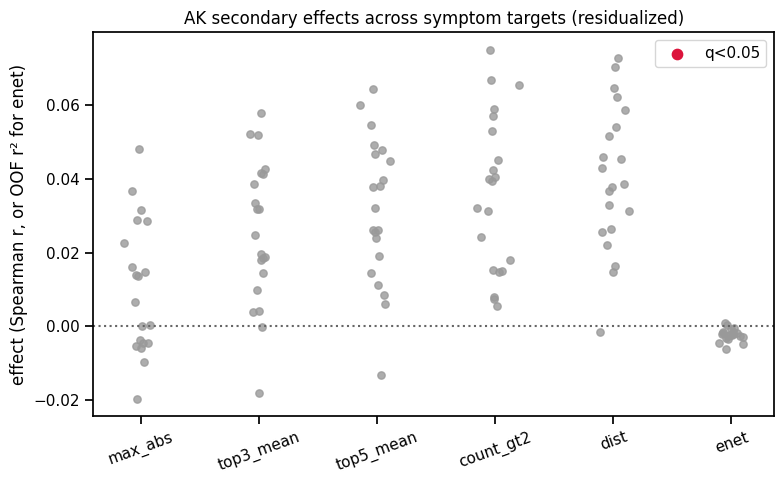

In [3]:
sec = res.filter((pl.col('variant') == 'resid') & (~pl.col('primary')))
approaches = ['max_abs', 'top3_mean', 'top5_mean', 'count_gt2', 'dist', 'enet']
fig, ax = plt.subplots(figsize=(8, 5))
for i, ap in enumerate(approaches):
    d = sec.filter(pl.col('approach') == ap)
    eff = d['effect'].to_numpy(); q = d['fdr_q'].to_numpy()
    x = np.full(len(eff), i) + np.random.default_rng(i).normal(0, 0.06, len(eff))
    ax.scatter(x[q >= 0.05], eff[q >= 0.05], s=28, color='0.6', alpha=0.8)
    ax.scatter(x[q < 0.05], eff[q < 0.05], s=55, color='crimson', zorder=5, label='q<0.05' if i == 0 else None)
ax.axhline(0, ls=':', color='0.4')
ax.set_xticks(range(len(approaches))); ax.set_xticklabels(approaches, rotation=20)
ax.set_ylabel('effect (Spearman r, or OOF r² for enet)')
ax.set_title('AK secondary effects across symptom targets (residualized)')
ax.legend()
plt.tight_layout(); plt.show()

In [4]:
# How many secondary targets survive BH-FDR per approach (residualized)
summary = (sec.group_by('approach')
              .agg([(pl.col('fdr_q') < 0.05).sum().alias('n_sig'),
                    pl.len().alias('n_tests'),
                    pl.col('effect').abs().max().round(3).alias('max_abs_effect')]))
print(summary.sort('approach'))
print("\nResidualized secondary results surviving BH-FDR (per approach):")
print(sec.filter(pl.col('fdr_q') < 0.05).select(['approach', 'target', 'effect', 'p', 'fdr_q']))
# whole-table BH-FDR survivors (both variants)
allsig = res.filter((pl.col('fdr_q') < 0.05) & (~pl.col('primary')))
print("\nAll secondary BH-FDR survivors (raw + resid):")
print(allsig.select(['approach', 'target', 'variant', 'effect', 'p', 'fdr_q']))
print("\nWith nested-CV selection + true OOF R^2, the elastic-net is null everywhere")
print("(0 survivors; max OOF R^2 ~0.006) -- the earlier floor-p 'hits' were an artifact")
print("of selecting hyperparameters on the full outcome. The only remaining BH-FDR")
print("survivor is the unsupervised count_gt2 -> hitop_hypsom (raw), which does NOT")
print("survive the family-wise maxT (section 4).")

shape: (6, 4)
┌───────────┬───────┬─────────┬────────────────┐
│ approach  ┆ n_sig ┆ n_tests ┆ max_abs_effect │
│ ---       ┆ ---   ┆ ---     ┆ ---            │
│ str       ┆ u32   ┆ u32     ┆ f64            │
╞═══════════╪═══════╪═════════╪════════════════╡
│ count_gt2 ┆ 0     ┆ 21      ┆ 0.075          │
│ dist      ┆ 0     ┆ 21      ┆ 0.073          │
│ enet      ┆ 0     ┆ 20      ┆ 0.006          │
│ max_abs   ┆ 0     ┆ 20      ┆ 0.048          │
│ top3_mean ┆ 0     ┆ 21      ┆ 0.058          │
│ top5_mean ┆ 0     ┆ 21      ┆ 0.064          │
└───────────┴───────┴─────────┴────────────────┘

Residualized secondary results surviving BH-FDR (per approach):
shape: (0, 5)
┌──────────┬────────┬────────┬─────┬───────┐
│ approach ┆ target ┆ effect ┆ p   ┆ fdr_q │
│ ---      ┆ ---    ┆ ---    ┆ --- ┆ ---   │
│ str      ┆ str    ┆ f64    ┆ f64 ┆ f64   │
╞══════════╪════════╪════════╪═════╪═══════╡
└──────────┴────────┴────────┴─────┴───────┘

All secondary BH-FDR survivors (raw + resid):
sh

## 3. Permutation p-value distribution (secondary tests)

Under a true null with valid permutation tests, p-values are ~uniform. A spike near 0 would indicate real signal; here they are close to uniform.

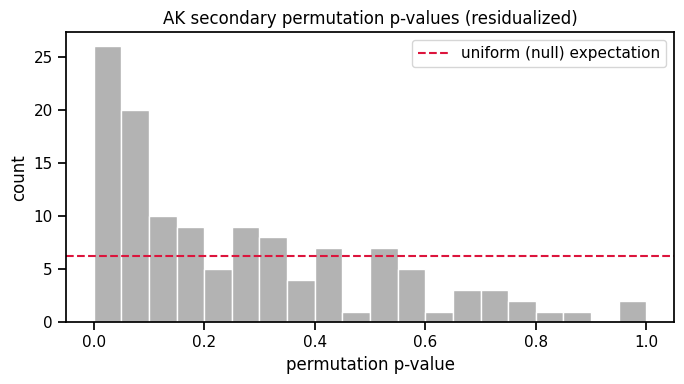

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sec['p'].to_numpy(), bins=20, range=(0, 1), color='0.7', edgecolor='white')
ax.axhline(sec.height / 20, ls='--', color='crimson', label='uniform (null) expectation')
ax.set_xlabel('permutation p-value'); ax.set_ylabel('count')
ax.set_title('AK secondary permutation p-values (residualized)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Family-wise correction: Westfall–Young step-down maxT

BH-FDR (above) controls the false-discovery rate; here we control the family-wise error rate with a **step-down maxT** permutation correction (`anna_karenina.maxstat_correction`). A single shared subject permutation is applied across the whole unsupervised family each iteration, so the correction accounts for the correlation among the (near-duplicate) approaches and overlapping symptom scales. One-sided (positive), residualized targets.

Two family definitions:
- **joint** — the full 5 approaches × 21 residualized targets (105 tests) as one family (`adj_p_maxT`)
- **within-approach** — each approach's 21 targets as its own family (`within_maxT`); less conservative, but FWER controlled only within, not across, approaches

In [6]:
data = ak.load_ak_data("../data/exploratory/normative_deviations.pkl",
                       "../data/exploratory/training_data.csv")
resid = [t for t in ak.symptom_targets(data) if t.variant == 'resid']
joint, _ = ak.maxstat_correction(data.absz, resid, n_perm=10000, seed=0)
within = ak.maxstat_within_approach(data.absz, resid, n_perm=10000, seed=0)
n_fam = 5 * len(resid)
print(f"joint family: 5 approaches x {len(resid)} targets = {n_fam} tests")
print(f"joint survivors (adj_p_maxT<0.05):        {joint.filter(pl.col('adj_p_maxT')<0.05).height}")
print(f"within-approach survivors (within_maxT<0.05): {within.filter(pl.col('within_maxT')<0.05).height}")

top = (joint.head(5).join(within.select(['approach', 'target', 'within_maxT']),
                          on=['approach', 'target'], how='left')
            .select(['approach', 'target', 'effect', 'adj_p_maxT', 'within_maxT'])
            .with_columns([pl.col(c).round(4) for c in ['effect', 'adj_p_maxT', 'within_maxT']]))
print("\nTop 5 by joint maxT (hitop_hypsom = hyposomnia):")
print(top)

joint family: 5 approaches x 21 targets = 105 tests
joint survivors (adj_p_maxT<0.05):        0
within-approach survivors (within_maxT<0.05): 2

Top 5 by joint maxT (hitop_hypsom = hyposomnia):
shape: (5, 5)
┌───────────┬──────────────┬────────┬────────────┬─────────────┐
│ approach  ┆ target       ┆ effect ┆ adj_p_maxT ┆ within_maxT │
│ ---       ┆ ---          ┆ ---    ┆ ---        ┆ ---         │
│ str       ┆ str          ┆ f64    ┆ f64        ┆ f64         │
╞═══════════╪══════════════╪════════╪════════════╪═════════════╡
│ count_gt2 ┆ hitop_hypsom ┆ 0.0751 ┆ 0.0801     ┆ 0.0393      │
│ dist      ┆ hitop        ┆ 0.0729 ┆ 0.0967     ┆ 0.0488      │
│ dist      ┆ hitop_anxwor ┆ 0.0703 ┆ 0.1198     ┆ 0.0595      │
│ count_gt2 ┆ hitop        ┆ 0.067  ┆ 0.1521     ┆ 0.0768      │
│ count_gt2 ┆ hitop_anxwor ┆ 0.0654 ┆ 0.1693     ┆ 0.0864      │
└───────────┴──────────────┴────────┴────────────┴─────────────┘


In [7]:
with pl.Config(tbl_rows=40):
   
    print(within.filter(pl.col('approach') == 'count_gt2'))

shape: (21, 6)
┌───────────┬─────────────────────┬─────────┬──────────┬─────────────┬─────────┐
│ approach  ┆ target              ┆ variant ┆ effect   ┆ within_maxT ┆ primary │
│ ---       ┆ ---                 ┆ ---     ┆ ---      ┆ ---         ┆ ---     │
│ str       ┆ str                 ┆ str     ┆ f64      ┆ f64         ┆ bool    │
╞═══════════╪═════════════════════╪═════════╪══════════╪═════════════╪═════════╡
│ count_gt2 ┆ hitop_hypsom        ┆ resid   ┆ 0.075073 ┆ 0.039296    ┆ false   │
│ count_gt2 ┆ hitop               ┆ resid   ┆ 0.066961 ┆ 0.076792    ┆ false   │
│ count_gt2 ┆ hitop_anxwor        ┆ resid   ┆ 0.065449 ┆ 0.086391    ┆ false   │
│ count_gt2 ┆ hitop_anhdep        ┆ resid   ┆ 0.05911  ┆ 0.135486    ┆ false   │
│ count_gt2 ┆ hitop_socanx        ┆ resid   ┆ 0.05697  ┆ 0.156684    ┆ false   │
│ count_gt2 ┆ baars_hyperactivity ┆ resid   ┆ 0.052955 ┆ 0.192281    ┆ false   │
│ count_gt2 ┆ gad7                ┆ resid   ┆ 0.04518  ┆ 0.288271    ┆ false   │
│ count_gt2 ┆

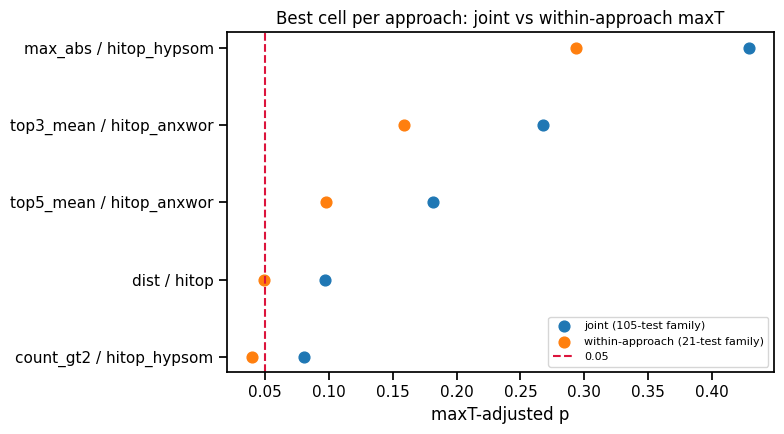

In [8]:
# joint vs within-approach adjusted p for the strongest cell per approach
best = (joint.sort('adj_p_maxT').group_by('approach', maintain_order=True).first()
             .join(within.select(['approach', 'target', 'within_maxT']), on=['approach', 'target'], how='left'))
fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(best.height)
ax.scatter(best['adj_p_maxT'], y, s=60, label='joint (105-test family)', color='C0')
ax.scatter(best['within_maxT'], y, s=60, label='within-approach (21-test family)', color='C1')
ax.axvline(0.05, ls='--', color='crimson', label='0.05')
ax.set_yticks(y); ax.set_yticklabels([f"{a} / {t}" for a, t in zip(best['approach'], best['target'])])
ax.set_xlabel('maxT-adjusted p'); ax.set_title('Best cell per approach: joint vs within-approach maxT')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 5. Conclusion

**The Anna Karenina hypothesis is not supported in the training half** (N=1298, after the same `max_rhat>1.1` exclusion as the CCA / XGBoost analyses).

- **Primary** (max|z| → PC1 general factor, residualized): null — r≈0.01, p≈0.36. The supervised elastic-net on PC1-resid is also null.
- **Supervised elastic-net (rebuilt):** with hyperparameters selected by nested CV *inside* each fold and the true out-of-fold R²=1−SSE/SST (each permutation re-running the full pipeline), the arm is **null across every target** (0 survive BH-FDR; max OOF R² ≈ 0.006). The four/nine floor-p "hits" seen previously were an artifact of selecting hyperparameters on the full observed outcome and an OOF-r² null centred below zero — they disappear under valid inference.
- **Family-wise maxT (the honest headline):** across the joint 5-approach × 21-target unsupervised family, **nothing survives** (0 at adj_p<0.05; strongest is `count_gt2 → hitop_hypsom`, adj_p≈0.08). Within-approach, two cells are borderline (`count_gt2 → hitop_hypsom` 0.039; `dist → hitop` 0.049). That lead was borderline-significant at N=1399 (joint adj_p≈0.035); with the cleaner rhat-excluded sample it weakens to non-significant.
- **BH-FDR** leaves a single secondary survivor, the unsupervised `count_gt2 → hitop_hypsom` (raw, q≈0.02); its residualized form is not significant and it does not survive the family-wise maxT.
- Effect sizes everywhere are tiny (|r| ≤ 0.10; best OOF R² ≈ 0.006), and permutation p-values are ~uniform.

This matches the CCA-ladder and XGBoost nulls: the fitted cognitive-model parameters carry very little information about symptoms in this sample — whether modeled as *shared* (CCA), *nonlinear-predictive* (XGBoost), or *idiosyncratic* (AK).

**Recommendation:** do not spend the reserved held-out half confirming this — the training-half exploratory result is null, so a confirmatory test is not warranted. Everything here used the training half only.